<a href="https://colab.research.google.com/github/ronin552/myname-ronin/blob/main/ronin123123123123.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import scipy.stats as stats
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", None)

In [ ]:
url = "https://raw.githubusercontent.com/frontiertechinstitute/datasets/refs/heads/main/LendingClub%20Loans/lendingclub_loans_clean.csv"
df = pd.read_csv(url)


In [ ]:
df = pd.read_csv(url)

df = df.drop_duplicates()
df = df.drop(columns=["Unnamed: 0"])
df = df.drop(columns=["issue_month"])
df = df.drop(columns=["num_accounts_120d_past_due"])
df = df.drop(columns=["num_accounts_30d_past_due"])
df = df.drop(columns=["current_accounts_delinq"])
df = df.drop(columns=["debt_to_income_joint"])
df = df.drop(columns=["months_since_90d_late"])
df = df.drop(columns=["months_since_last_delinq"])

df['emp_length'] = pd.to_numeric(df['emp_length'], errors='coerce').fillna(-1)
df.dropna(axis=0 or 1, how="all", subset =None)

df.head()

,emp_title,emp_length,state,homeownership,annual_income,verified_income,debt_to_income,delinq_2y,earliest_credit_line,inquiries_last_12m,total_credit_lines,open_credit_lines,total_credit_limit,total_credit_utilized,num_collections_last_12m,num_historical_failed_to_pay,total_collection_amount_ever,current_installment_accounts,accounts_opened_24m,months_since_last_credit_inquiry,num_satisfactory_accounts,num_active_debit_accounts,total_debit_limit,num_total_cc_accounts,num_open_cc_accounts,num_cc_carrying_balance,num_mort_accounts,account_never_delinq_percent,tax_liens,public_record_bankrupt,loan_purpose,application_type,loan_amount,term,interest_rate,installment,sub_grade,loan_status,initial_listing_status,disbursement_method,balance,paid_total,paid_principal,paid_interest,paid_late_fees
0,global config engineer,3.0,NJ,MORTGAGE,90000.0,Verified,18.01,0,2001,6,28,10,70795,38767,0,0,1250,2,5,5.0,10,2,11100,14,8,6,1,92.9,0,0,moving,individual,28000,60,14.07,652.53,C3,Current,whole,Cash,27015.86,1999.33,984.14,1015.19,0.0
1,warehouse office clerk,10.0,HI,RENT,40000.0,Not Verified,5.04,0,1996,1,30,14,28800,4321,0,1,0,0,11,8.0,14,3,16500,24,14,4,0,100.0,0,1,debt_consolidation,individual,5000,36,12.61,167.54,C1,Current,whole,Cash,4651.37,499.12,348.63,150.49,0.0
2,assembly,3.0,WI,RENT,40000.0,Source Verified,21.15,0,2006,4,31,10,24193,16000,0,0,432,1,13,7.0,10,3,4300,14,8,6,0,93.5,0,0,other,individual,2000,36,17.09,71.40,D1,Current,fractional,Cash,1824.63,281.80,175.37,106.43,0.0
3,customer service,1.0,PA,RENT,30000.0,Not Verified,10.16,0,2007,0,4,4,25400,4997,0,1,0,1,1,15.0,4,2,19400,3,3,2,0,100.0,1,0,debt_consolidation,individual,21600,36,6.72,664.19,A3,Current,whole,Cash,18853.26,3312.89,2746.74,566.15,0.0
4,security supervisor,10.0,CA,RENT,35000.0,Verified,57.96,0,2008,7,22,16,69839,52722,0,0,0,1,6,4.0,16,10,32700,20,15,13,0,100.0,0,0,credit_card,joint,23000,36,14.07,786.87,C3,Current,whole,Cash,21430.15,2324.65,1569.85,754.80,0.0


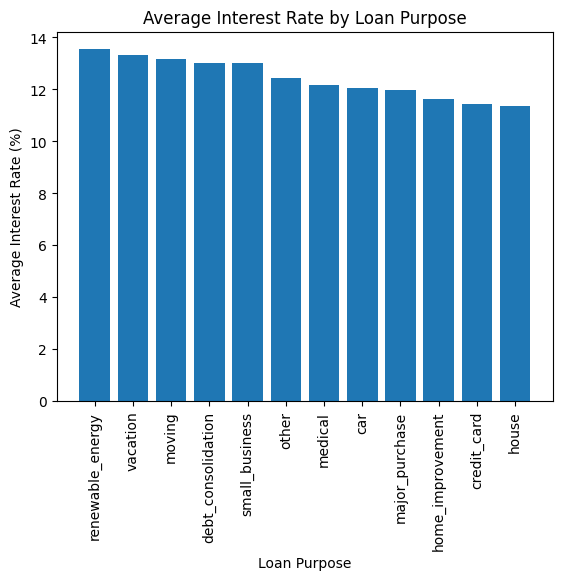

In [ ]:
avg_rate = df.groupby("loan_purpose")["interest_rate"].mean().sort_values(ascending=False)

x = avg_rate.index
y = avg_rate.values
plt.bar(x, y)
plt.title("Average Interest Rate by Loan Purpose")
plt.xlabel("Loan Purpose")
plt.ylabel("Average Interest Rate (%)")
plt.xticks(rotation=90)
plt.show()

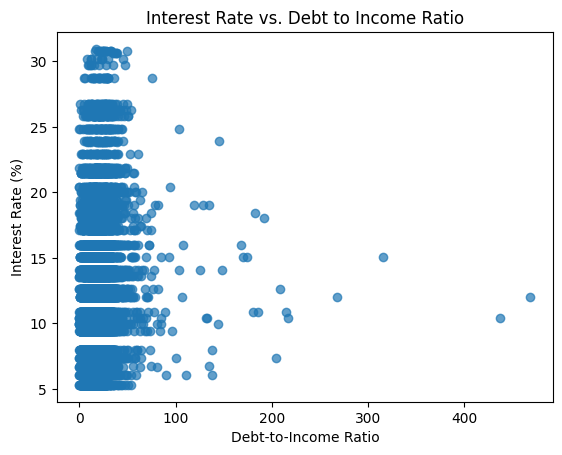

In [ ]:
x = df["debt_to_income"]
y = df["interest_rate"]

plt.scatter(x, y, alpha=0.7)

plt.title("Interest Rate vs. Debt to Income Ratio")
plt.xlabel("Debt-to-Income Ratio")
plt.ylabel("Interest Rate (%)")

plt.show()

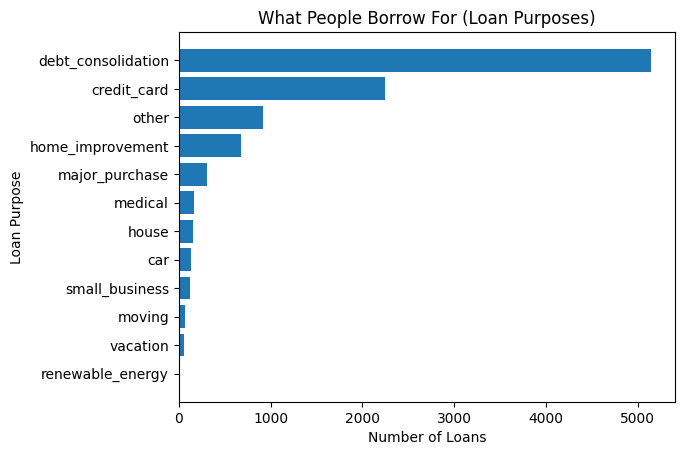

In [ ]:
purpose_counts = df["loan_purpose"].value_counts().reset_index()
purpose_counts.columns = ["loan_purpose", "count"]
purpose_counts = purpose_counts.sort_values(by="count", ascending=True)

y = purpose_counts["loan_purpose"]
x = purpose_counts["count"]

plt.barh(y, x)

plt.title("What People Borrow For (Loan Purposes)")
plt.xlabel("Number of Loans")
plt.ylabel("Loan Purpose")
plt.show()

In [ ]:
df.isnull().sum()

,0
emp_title,833
emp_length,0
state,0
homeownership,0
annual_income,0
verified_income,0
debt_to_income,24
delinq_2y,0
earliest_credit_line,0
inquiries_last_12m,0


Do average loan amounts differ across loan purposes?

Null Hypothesis :
The mean loan amount is the same for all loan purposes.

Alternative Hypothesis :
At least one loan purpose has a different mean loan amount.

In [ ]:
groups = [group["loan_amount"]for _, group in df.groupby("loan_purpose")]

f_stat, p_val = stats.f_oneway(*groups)

print("F-statistic:", f_stat)
print("P-value:", p_val)


F-statistic: 36.10233579861125
P-value: 9.816214856332122e-77


Is the average loan amount for debt consolidation loans greater than the average loan amount for credit card loans?

Null Hypothesis :
The average loan amounts are equal.

Alternative Hypothesis :
Debt consolidation loans have a greater average loan amount.

In [ ]:
group1 = df.loc[df["loan_purpose"] == "debt_consolidation", "loan_amount"]

group2 = df.loc[df["loan_purpose"] == "credit_card","loan_amount"]

t_stat, p_val = stats.ttest_ind(group1, group2, alternative="greater")

print("T-statistic:", t_stat)
print("P-value:", p_val)


T-statistic: 8.355683745534447
P-value: 3.849779499900199e-17


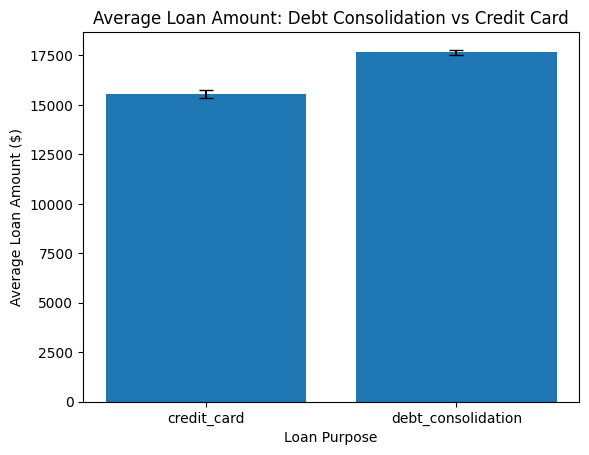

In [9]:
avg_amount = df[df["loan_purpose"].isin(["debt_consolidation", "credit_card"])] \
    .groupby("loan_purpose")["loan_amount"].mean()

sem_amount = df[df["loan_purpose"].isin(["debt_consolidation", "credit_card"])] \
    .groupby("loan_purpose")["loan_amount"].sem()

x = avg_amount.index
y = avg_amount.values
err = sem_amount.values

plt.bar(x, y, yerr=err, capsize=5)
plt.title("Average Loan Amount: Debt Consolidation vs Credit Card")
plt.xlabel("Loan Purpose")
plt.ylabel("Average Loan Amount ($)")
plt.show()